# 2. Feature Extraction

## Summary
This notebook transforms the preprocessed audio segments (output of notebook 01) into fixed-size
feature tensors for **all three** DronePrint classifiers:

- **X** - drone detection (`drone` vs `non_drone`)
- **Y** - drone *make* identification (`DJI`, `Parrot`, `Autel`, `Feima`, `MikroKopter` - whichever
  are present in your data)
- **Z** - drone *model* identification, one classifier per make that has &ge;2 distinct models
  in your data (e.g. `Z_DJI`, `Z_Parrot`)

### Pipeline
1. Load `final_preprocessed_metadata.csv` (output of notebook 01 - now carries `label`, `model`,
   `make` and `split` columns);
2. Extract **MFCC** features (40 coefficients, 0-8 kHz) following DronePrint Section 4;
3. Apply **peak normalisation** per 200ms frame and **L2 feature-vector rescaling** (Section 4.2 /
   4.4);
4. Cut each (T, 40) MFCC matrix into (10, 40) windows - DronePrint's LSTM input shape (Fig. 8);
5. Build the X / Y / Z feature sets, balancing Y and Z (Section 5.1);
6. Persist everything as `.npy` + label-encoder `.json` files, split into train/val/test using the
   `split` column from notebook 01 (**not** a fresh random split - that would leak data, see notebook
   01 §1.2.1.c).

### Key design decisions (aligned with DronePrint)
- Sample rate: **44 100 Hz**
- Frame size: **200 ms** (8 820 samples), **no overlap**
- MFCC: **40 coefficients**, Mel filterbanks spanning **0-8 kHz**
- Feature matrix shape per segment: **(T, 40)** where T = number of frames
- Window fed to the LSTM: **(10, 40)** - 10 frames &times; 40 MFCCs &asymp; 2 s
  (**no channel dimension** - that was a CNN-specific reshape; DronePrint's classifier is an LSTM,
  see Fig. 8 and notebook 03)

### Imports

In [1]:
import os
import json
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Audio / MFCC constants (DronePrint §4) ───
SAMPLE_RATE   = 44_100
FRAME_MS      = 200          # ms per frame
FRAME_SAMPLES = int(FRAME_MS * SAMPLE_RATE / 1000)  # 8 820
N_MFCC        = 40
FMAX          = 8_000        # Hz  (DronePrint focuses on 0-8 kHz)
N_FFT         = 2048
HOP_LENGTH    = FRAME_SAMPLES   # no overlap between frames
N_FRAMES      = 10          # context window fed to the LSTM (≈ 2 s at 200 ms/frame)

print(f"Frame duration : {FRAME_MS} ms  ({FRAME_SAMPLES} samples)")
print(f"Context window : {N_FRAMES} frames = {N_FRAMES * FRAME_MS / 1000:.1f} s")
print(f"MFCC shape     : ({N_FRAMES}, {N_MFCC}) per sample  (no channel dim - LSTM input)")


Frame duration : 200 ms  (8820 samples)
Context window : 10 frames = 2.0 s
MFCC shape     : (10, 40) per sample  (no channel dim - LSTM input)


## 2.1  Load metadata

In [2]:
METADATA_PATH = "final_preprocessed_metadata.csv"   # written by notebook 01

df = pd.read_csv(METADATA_PATH)
print(f"Total segments : {len(df)}")
print(df["label"].value_counts())
print()
print(df.groupby(["split", "label"]).size().unstack(fill_value=0))
df.head()

Total segments : 5327
label
non_drone    3825
drone        1502
Name: count, dtype: int64

label  drone  non_drone
split                  
test      53         45
train    714       2835
val      735        945


,file_path,label,model,make,split
0,./data/augmented_segments\DS1_Bebop2_drone_Beb...,drone,Bebop2,Parrot,val
1,./data/augmented_segments\DS1_Bebop2_drone_Beb...,drone,Bebop2,Parrot,val
2,./data/augmented_segments\DS1_Bebop2_drone_Beb...,drone,Bebop2,Parrot,val
3,./data/augmented_segments\DS1_Bebop2_drone_Beb...,drone,Bebop2,Parrot,val
4,./data/augmented_segments\DS1_Bebop2_drone_Beb...,drone,Bebop2,Parrot,val


## 2.2  MFCC extraction helpers

In [3]:
def peak_normalize_frame(frame: np.ndarray) -> np.ndarray:
    """Time-domain peak normalisation per 200 ms frame (DronePrint §4.2)."""
    peak = np.max(np.abs(frame))
    return frame / peak if peak > 0.0 else frame


def l2_normalize_vector(vec: np.ndarray) -> np.ndarray:
    """Feature-vector L2 rescaling (DronePrint §4.4)."""
    norm = np.linalg.norm(vec)
    return vec / norm if norm > 0.0 else vec


def extract_mfcc_matrix(file_path: str) -> np.ndarray | None:
    """
    Load one audio segment and return a (T, N_MFCC) MFCC matrix.

    Processing order:
        1. Load at 44 100 Hz
        2. Split into 200 ms non-overlapping frames
        3. Peak-normalise each frame
        4. Compute 40 MFCCs (0-8 kHz Mel scale)
        5. L2-normalise each MFCC vector
    Returns None if the file is too short.
    """
    try:
        y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)
    except Exception:
        return None

    n_frames = len(y) // FRAME_SAMPLES
    if n_frames == 0:
        return None

    mfcc_rows = []
    for i in range(n_frames):
        frame = y[i * FRAME_SAMPLES : (i + 1) * FRAME_SAMPLES]
        frame = peak_normalize_frame(frame)

        # librosa MFCC on a single frame
        mfcc = librosa.feature.mfcc(
            y=frame, sr=sr,
            n_mfcc=N_MFCC,
            n_fft=N_FFT,
            hop_length=len(frame) + 1,   # single column
            fmax=FMAX,
        )                                # shape: (N_MFCC, 1)
        mfcc_vec = mfcc[:, 0]            # shape: (N_MFCC,)
        mfcc_vec = l2_normalize_vector(mfcc_vec)
        mfcc_rows.append(mfcc_vec)

    return np.array(mfcc_rows)           # (n_frames, N_MFCC)


def sliding_windows(matrix: np.ndarray, n_frames: int = N_FRAMES) -> np.ndarray:
    """
    Cut a (T, 40) MFCC matrix into non-overlapping (n_frames, 40) windows.
    Returns array of shape (n_windows, n_frames, 40).
    """
    T = matrix.shape[0]
    n_windows = T // n_frames
    if n_windows == 0:
        return np.empty((0, n_frames, N_MFCC))
    windows = []
    for i in range(n_windows):
        windows.append(matrix[i * n_frames : (i + 1) * n_frames])
    return np.array(windows)             # (n_windows, 10, 40)


print("Helper functions defined.")


Helper functions defined.


## 2.3  Visualise MFCC features

In [4]:
# ── Pick one drone and one non-drone sample ──────────────────────────────────
drone_file    = df[df["label"] == "drone"].iloc[0]["file_path"]
nondrone_file = df[df["label"] == "non_drone"].iloc[0]["file_path"]

drone_mfcc    = extract_mfcc_matrix(drone_file)
nondrone_mfcc = extract_mfcc_matrix(nondrone_file)

print(f"Drone MFCC matrix   : {drone_mfcc.shape}   (frames × coefficients)")
print(f"Non-drone MFCC matrix: {nondrone_mfcc.shape}")


Drone MFCC matrix   : (10, 40)   (frames × coefficients)
Non-drone MFCC matrix: (10, 40)


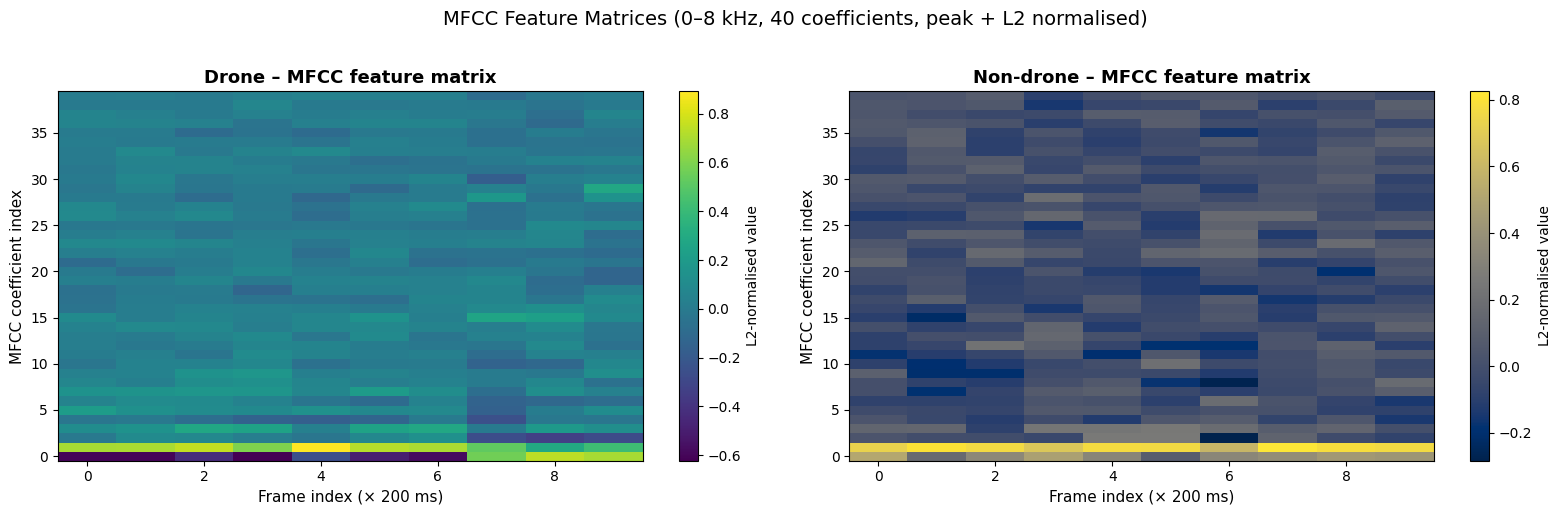

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, mfcc, title, cmap in zip(
        axes,
        [drone_mfcc, nondrone_mfcc],
        ["Drone – MFCC feature matrix", "Non-drone – MFCC feature matrix"],
        ["viridis", "cividis"]):
    img = ax.imshow(mfcc.T, aspect="auto", origin="lower", cmap=cmap)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Frame index (× 200 ms)", fontsize=11)
    ax.set_ylabel("MFCC coefficient index", fontsize=11)
    plt.colorbar(img, ax=ax, label="L2-normalised value")

plt.suptitle("MFCC Feature Matrices (0–8 kHz, 40 coefficients, peak + L2 normalised)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("plots/mfcc_matrices_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


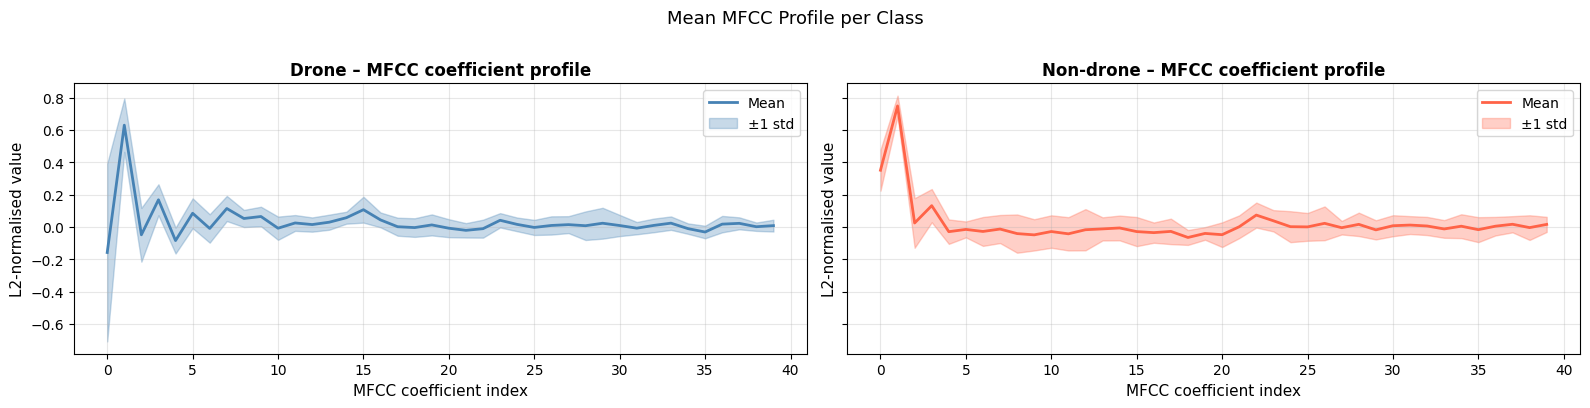

In [6]:
# ── Per-coefficient mean ± std across all frames ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharey=True)

for ax, mfcc, title, color in zip(
        axes,
        [drone_mfcc, nondrone_mfcc],
        ["Drone", "Non-drone"],
        ["steelblue", "tomato"]):
    mean = mfcc.mean(axis=0)
    std  = mfcc.std(axis=0)
    x    = np.arange(N_MFCC)
    ax.plot(x, mean, color=color, linewidth=2, label="Mean")
    ax.fill_between(x, mean - std, mean + std, alpha=0.3, color=color, label="±1 std")
    ax.set_title(f"{title} – MFCC coefficient profile", fontsize=12, fontweight="bold")
    ax.set_xlabel("MFCC coefficient index", fontsize=11)
    ax.set_ylabel("L2-normalised value", fontsize=11)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle("Mean MFCC Profile per Class", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("plots/mfcc_mean_profile.png", dpi=150, bbox_inches="tight")
plt.show()


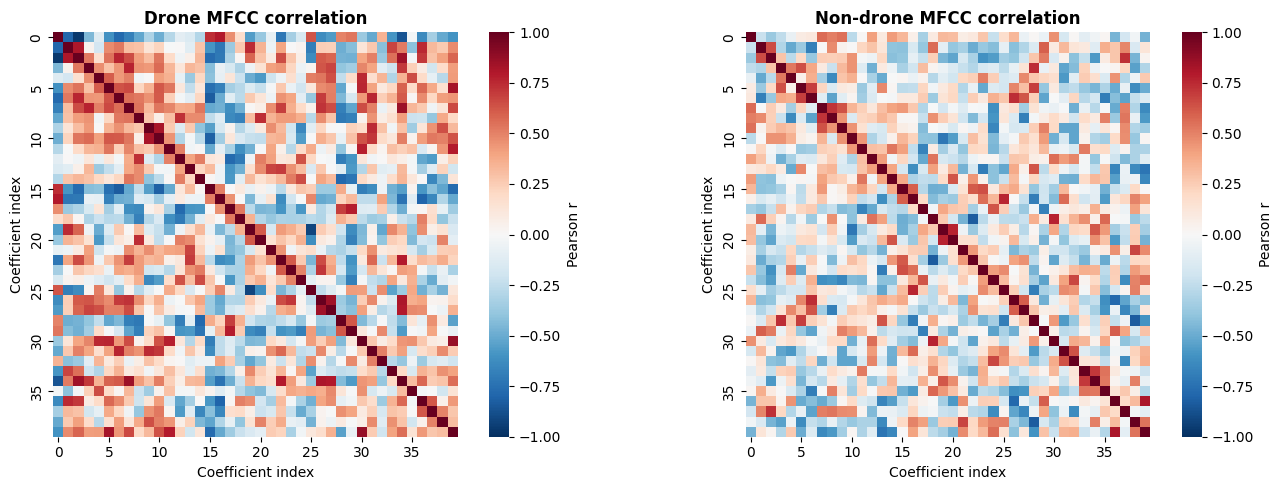

In [7]:
# ── Correlation heatmap of MFCC coefficients (drone vs non-drone) ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mfcc, title in zip(
        axes,
        [drone_mfcc, nondrone_mfcc],
        ["Drone MFCC correlation", "Non-drone MFCC correlation"]):
    corr = np.corrcoef(mfcc.T)
    sns.heatmap(corr, ax=ax, cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, square=True,
                xticklabels=5, yticklabels=5, cbar_kws={"label": "Pearson r"})
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Coefficient index")
    ax.set_ylabel("Coefficient index")

plt.tight_layout()
plt.savefig("plots/mfcc_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


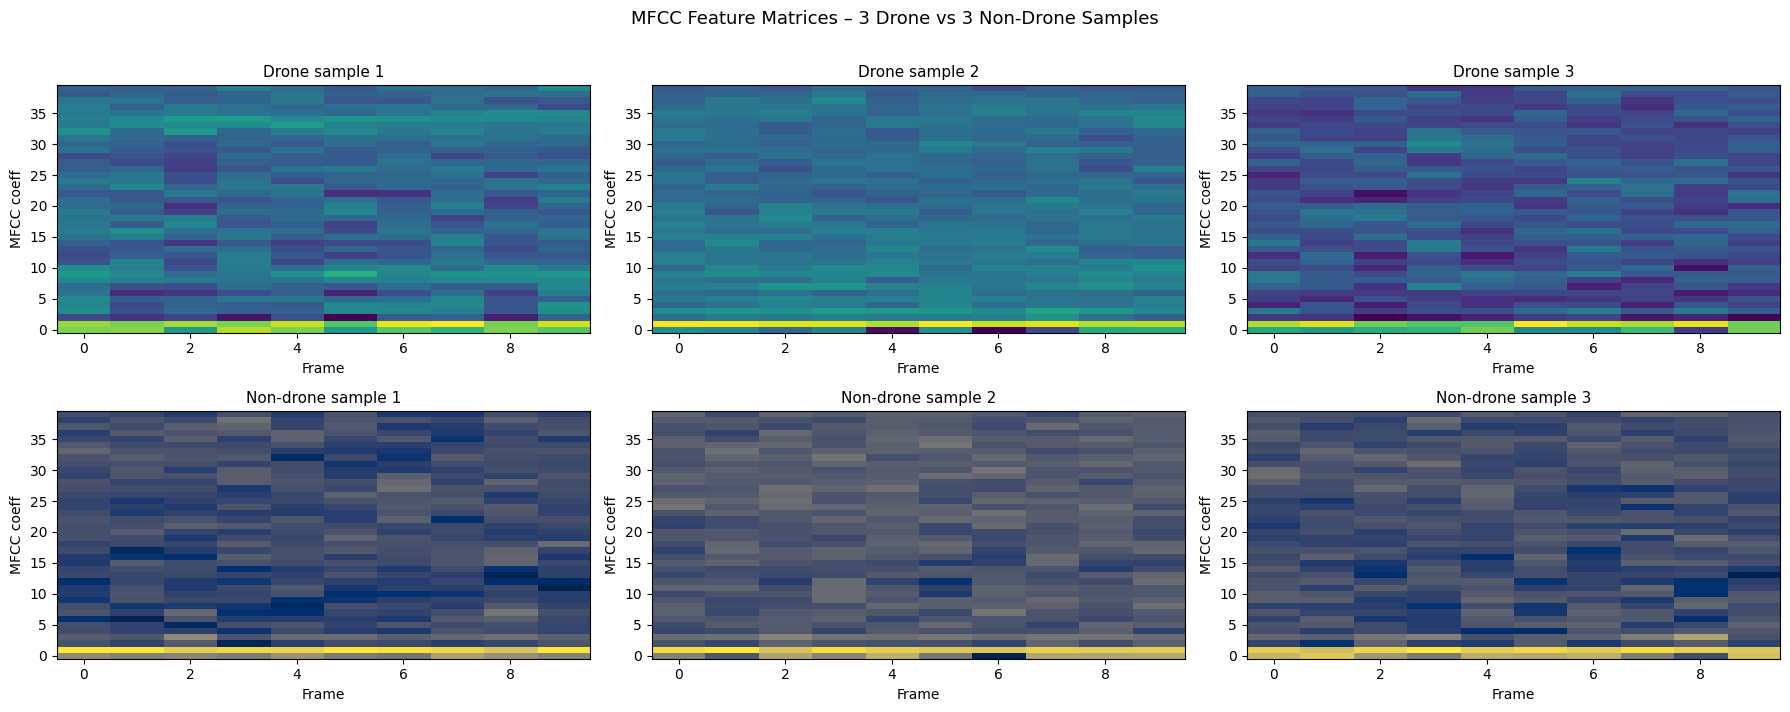

In [8]:
# ── MFCC spectrogram-style comparison across multiple samples ─────────────────
os.makedirs("plots", exist_ok=True)

drone_samples    = df[df["label"] == "drone"].sample(3, random_state=SEED)["file_path"].tolist()
nondrone_samples = df[df["label"] == "non_drone"].sample(3, random_state=SEED)["file_path"].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 7))

for col, path in enumerate(drone_samples):
    mfcc = extract_mfcc_matrix(path)
    if mfcc is None: continue
    axes[0, col].imshow(mfcc.T, aspect="auto", origin="lower", cmap="viridis")
    axes[0, col].set_title(f"Drone sample {col+1}", fontsize=11)
    axes[0, col].set_xlabel("Frame")
    axes[0, col].set_ylabel("MFCC coeff")

for col, path in enumerate(nondrone_samples):
    mfcc = extract_mfcc_matrix(path)
    if mfcc is None: continue
    axes[1, col].imshow(mfcc.T, aspect="auto", origin="lower", cmap="cividis")
    axes[1, col].set_title(f"Non-drone sample {col+1}", fontsize=11)
    axes[1, col].set_xlabel("Frame")
    axes[1, col].set_ylabel("MFCC coeff")

plt.suptitle("MFCC Feature Matrices – 3 Drone vs 3 Non-Drone Samples", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("plots/mfcc_sample_grid.png", dpi=150, bbox_inches="tight")
plt.show()


## 2.4  Build the detection (Classifier X) dataset

One window per 2 s segment (10 frames &times; 200ms = 2 s, so every segment yields exactly one
`(10, 40)` window). We split using the `split` column carried over from notebook 01, so files from
the same source recording never cross train/val/test.

In [9]:
os.makedirs("plots", exist_ok=True)

LABEL_MAP_X = {"drone": 1, "non_drone": 0, "unknown": -1}  # 'unknown' -> DS3, used only for open-set eval


def build_windows_for_rows(rows_df, label_series, desc):
    """Extract MFCC windows + integer labels for every row in `rows_df`."""
    X_list, y_list, idx_list = [], [], []
    skipped = 0
    for i, ((_, row), label) in enumerate(tqdm(list(zip(rows_df.iterrows(), label_series)), desc=desc)):
        if label == -1:
            skipped += 1
            continue
        mfcc_matrix = extract_mfcc_matrix(row["file_path"])
        if mfcc_matrix is None:
            skipped += 1
            continue
        windows = sliding_windows(mfcc_matrix)
        for w in windows:
            X_list.append(w)
            y_list.append(label)
            idx_list.append(row.name)
    X_arr = np.array(X_list, dtype=np.float32) if X_list else np.empty((0, N_FRAMES, N_MFCC), dtype=np.float32)
    y_arr = np.array(y_list, dtype=np.int32)
    print(f"  -> {X_arr.shape}  (skipped {skipped})")
    return X_arr, y_arr, idx_list


# Closed-set rows (drone / non_drone) used to train & validate Classifier X.
closed_df = df[df["label"].isin(["drone", "non_drone"])].copy()
closed_df["y"] = closed_df["label"].map(LABEL_MAP_X)

X_detect, y_detect = {}, {}
for split_name in ["train", "val", "test"]:
    rows = closed_df[closed_df["split"] == split_name]
    Xw, yw, _ = build_windows_for_rows(rows, rows["y"].tolist(), desc=f"X[{split_name}]")
    X_detect[split_name], y_detect[split_name] = Xw, yw

# Open-set rows (DS3 'unknown') - test only, used in notebook 04 for open-set evaluation.
unknown_df = df[(df["label"] == "unknown") & (df["split"] != "train")]
if len(unknown_df) > 0:
    X_unknown, _, _ = build_windows_for_rows(unknown_df, [1] * len(unknown_df), desc="X[unknown/DS3]")
    print(f"Open-set (DS3) windows available for evaluation: {X_unknown.shape}")
else:
    X_unknown = np.empty((0, N_FRAMES, N_MFCC), dtype=np.float32)
    print("No DS3 ('unknown') data found - open-set evaluation in notebook 04 will be skipped/limited. "
          "Download DS3 from the DronePrint dataset to enable it.")

X[train]: 100%|██████████| 3549/3549 [01:21<00:00, 43.69it/s]


  -> (3549, 10, 40)  (skipped 0)


X[val]: 100%|██████████| 1680/1680 [00:41<00:00, 40.34it/s]


  -> (1680, 10, 40)  (skipped 0)


X[test]: 100%|██████████| 98/98 [00:02<00:00, 39.22it/s]

  -> (98, 10, 40)  (skipped 0)
No DS3 ('unknown') data found - open-set evaluation in notebook 04 will be skipped/limited. Download DS3 from the DronePrint dataset to enable it.


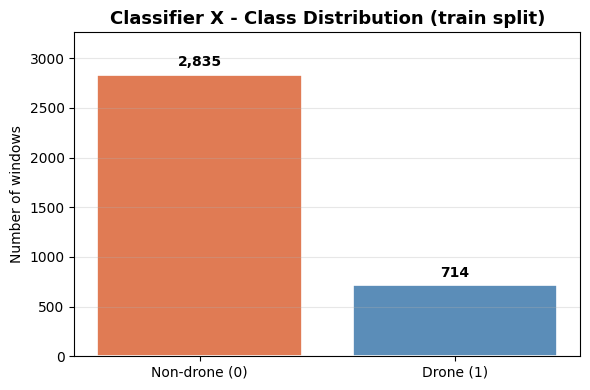

In [10]:
# ── Class balance bar chart (train split) ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
classes = ["Non-drone (0)", "Drone (1)"]
counts = [(y_detect["train"] == 0).sum(), (y_detect["train"] == 1).sum()]
colors = ["#e07b54", "#5b8db8"]
bars = ax.bar(classes, counts, color=colors, edgecolor="white", linewidth=1.2)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02 * max(counts + [1]),
            f"{count:,}", ha="center", va="bottom", fontweight="bold")

ax.set_title("Classifier X - Class Distribution (train split)", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of windows")
ax.set_ylim(0, max(counts + [1]) * 1.15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plots/class_distribution_X.png", dpi=150, bbox_inches="tight")
plt.show()

## 2.5  Save the detection (X) dataset

**No channel dimension** here - DronePrint's classifier is an LSTM (Fig. 8), which expects
`(batch, time_steps=10, features=40)`, unlike a CNN which would want a trailing channel axis.

In [11]:
for split_name in ["train", "val", "test"]:
    np.save(f"X_detect_{split_name}.npy", X_detect[split_name])
    np.save(f"y_detect_{split_name}.npy", y_detect[split_name])
    print(f"X_detect_{split_name}.npy -> {X_detect[split_name].shape}   "
          f"y_detect_{split_name}.npy -> {y_detect[split_name].shape}")

np.save("X_detect_unknown.npy", X_unknown)
print(f"X_detect_unknown.npy -> {X_unknown.shape}  (DS3, open-set eval only)")

X_detect_train.npy -> (3549, 10, 40)   y_detect_train.npy -> (3549,)
X_detect_val.npy -> (1680, 10, 40)   y_detect_val.npy -> (1680,)
X_detect_test.npy -> (98, 10, 40)   y_detect_test.npy -> (98,)
X_detect_unknown.npy -> (0, 10, 40)  (DS3, open-set eval only)


## 2.6  Build the make-identification (Classifier Y) dataset

Only `drone`-labelled windows are used. DronePrint Section 5.1 notes that the make-balanced
augmentation (cf. Section 4.1) does not naturally yield a balanced *make* distribution (DJI has 6
models, Parrot 4, the rest 1 each) - so they re-balance specifically for this stage:

> *"we augmented the training and validation samples of each drone type differently... only a part
> of the testing data is used from each of the DJI and Parrot drones to have a balanced testing
> dataset"* (Section 5.1)

The paper's exact multipliers (8x / 12x / 48x) were calibrated for the **full 13-model** dataset.
Since your local dataset is whatever subset of DS1 you've downloaded, we instead balance directly
to **equal counts**, which achieves the same goal the paper describes (a make-balanced train/val set,
and a make-balanced test set) regardless of how many models/makes are actually present:

- `train` / `val` &rarr; **oversample** minority makes (small Gaussian jitter on the duplicated
  copies only, so we don't insert exact duplicate rows) up to the majority make's count.
- `test` &rarr; **subsample** majority makes down to the minority make's count (matches the paper's
  "only a part of the testing data is used... to have a balanced testing dataset").

In [12]:
from sklearn.preprocessing import LabelEncoder

def balance_up(X, y, seed=SEED, jitter_sigma=0.01):
    """Oversample every class up to the size of the largest class."""
    rng = np.random.default_rng(seed)
    classes, counts = np.unique(y, return_counts=True)
    target = counts.max()
    X_out, y_out = [X], [y]
    for c, n in zip(classes, counts):
        deficit = target - n
        if deficit <= 0:
            continue
        pool = X[y == c]
        pick_idx = rng.integers(0, len(pool), size=deficit)
        extra = pool[pick_idx].copy()
        extra += rng.normal(0, jitter_sigma, extra.shape).astype(np.float32)
        X_out.append(extra)
        y_out.append(np.full(deficit, c, dtype=y.dtype))
    return np.concatenate(X_out), np.concatenate(y_out)


def balance_down(X, y, seed=SEED):
    """Subsample every class down to the size of the smallest non-empty class."""
    rng = np.random.default_rng(seed)
    classes, counts = np.unique(y, return_counts=True)
    target = counts.min()
    X_out, y_out = [], []
    for c in classes:
        pool_idx = np.where(y == c)[0]
        keep = rng.choice(pool_idx, size=target, replace=False)
        X_out.append(X[keep])
        y_out.append(y[keep])
    return np.concatenate(X_out), np.concatenate(y_out)


drone_df = df[df["label"] == "drone"].copy()
make_encoder = LabelEncoder()
make_encoder.fit(sorted(drone_df["make"].unique()))
print("Make classes:", list(make_encoder.classes_))

X_make, y_make = {}, {}
for split_name in ["train", "val", "test"]:
    rows = drone_df[drone_df["split"] == split_name]
    y_int = make_encoder.transform(rows["make"])
    Xw, yw, _ = build_windows_for_rows(rows, y_int.tolist(), desc=f"Y[{split_name}]")
    if split_name in ("train", "val") and len(yw) > 0:
        Xw, yw = balance_up(Xw, yw, seed=SEED)
    elif split_name == "test" and len(yw) > 0:
        Xw, yw = balance_down(Xw, yw, seed=SEED)
    X_make[split_name], y_make[split_name] = Xw, yw
    print(f"  balanced {split_name}: {Xw.shape}, class counts = "
          f"{dict(zip(*np.unique(yw, return_counts=True)))}")

Make classes: [np.str_('DJI'), np.str_('Parrot')]


Y[train]: 100%|██████████| 714/714 [00:10<00:00, 66.76it/s]


  -> (714, 10, 40)  (skipped 0)
  balanced train: (1218, 10, 40), class counts = {np.int32(0): np.int64(609), np.int32(1): np.int64(609)}


Y[val]: 100%|██████████| 735/735 [00:10<00:00, 67.11it/s]


  -> (735, 10, 40)  (skipped 0)
  balanced val: (840, 10, 40), class counts = {np.int32(0): np.int64(420), np.int32(1): np.int64(420)}


Y[test]: 100%|██████████| 53/53 [00:00<00:00, 66.21it/s]

  -> (53, 10, 40)  (skipped 0)
  balanced test: (10, 10, 40), class counts = {np.int32(0): np.int64(5), np.int32(1): np.int64(5)}


## 2.7  Save the make-identification (Y) dataset

In [13]:
for split_name in ["train", "val", "test"]:
    np.save(f"X_make_{split_name}.npy", X_make[split_name])
    np.save(f"y_make_{split_name}.npy", y_make[split_name])
    print(f"X_make_{split_name}.npy -> {X_make[split_name].shape}")

with open("make_label_encoder.json", "w") as f:
    json.dump({"classes": list(make_encoder.classes_)}, f, indent=2)
print("Saved make_label_encoder.json:", list(make_encoder.classes_))

X_make_train.npy -> (1218, 10, 40)
X_make_val.npy -> (840, 10, 40)
X_make_test.npy -> (10, 10, 40)
Saved make_label_encoder.json: [np.str_('DJI'), np.str_('Parrot')]


## 2.8  Build the per-make model-identification (Classifier Z) datasets

One classifier `Z_<MAKE>` is trained per make that has **2 or more distinct models** present in the
data (a make with only one model needs no further classifier - it's already fully identified once
Classifier Y says e.g. "Autel"). With only the `ExperimentallyCollected` subset of DS1 downloaded,
that typically means a `Z_DJI` classifier only; download the YouTube-Sourced /
Other-Online-Databases-Sourced parts of DS1 to also get enough Parrot models (Bebop2, Anafi, Bebop,
Membo) for a `Z_Parrot` classifier, matching the paper's Figure 11.

In [14]:
Z_datasets = {}   # make -> {"encoder": ..., "X": {...}, "y": {...}}

for make_name in sorted(drone_df["make"].unique()):
    make_rows_all = drone_df[drone_df["make"] == make_name]
    n_models = make_rows_all["model"].nunique()
    if n_models < 2:
        print(f"Skipping Z_{make_name}: only {n_models} model present ({list(make_rows_all['model'].unique())}).")
        continue

    print(f"\nBuilding Z_{make_name} ({n_models} models: {sorted(make_rows_all['model'].unique())})")
    model_encoder = LabelEncoder()
    model_encoder.fit(sorted(make_rows_all["model"].unique()))

    X_z, y_z = {}, {}
    for split_name in ["train", "val", "test"]:
        rows = make_rows_all[make_rows_all["split"] == split_name]
        y_int = model_encoder.transform(rows["model"])
        Xw, yw, _ = build_windows_for_rows(rows, y_int.tolist(), desc=f"Z_{make_name}[{split_name}]")
        if split_name in ("train", "val") and len(yw) > 0:
            Xw, yw = balance_up(Xw, yw, seed=SEED)
        elif split_name == "test" and len(yw) > 0:
            Xw, yw = balance_down(Xw, yw, seed=SEED)
        X_z[split_name], y_z[split_name] = Xw, yw
        print(f"  {split_name}: {Xw.shape}")

    Z_datasets[make_name] = {"encoder": model_encoder, "X": X_z, "y": y_z}


Building Z_DJI (4 models: ['Matrice100', 'MavicPro', 'Phantom4Pro', 'Spark'])


Z_DJI[train]: 100%|██████████| 609/609 [00:09<00:00, 67.35it/s]


  -> (609, 10, 40)  (skipped 0)
  train: (1176, 10, 40)


Z_DJI[val]: 100%|██████████| 420/420 [00:06<00:00, 67.16it/s]


  -> (420, 10, 40)  (skipped 0)
  val: (420, 10, 40)


Z_DJI[test]: 100%|██████████| 48/48 [00:00<00:00, 67.54it/s]

  -> (48, 10, 40)  (skipped 0)
  test: (20, 10, 40)
Skipping Z_Parrot: only 1 model present (['Bebop2']).


## 2.9  Save the Z (per-make model identification) datasets

In [15]:
for make_name, payload in Z_datasets.items():
    for split_name in ["train", "val", "test"]:
        np.save(f"X_model_{make_name}_{split_name}.npy", payload["X"][split_name])
        np.save(f"y_model_{make_name}_{split_name}.npy", payload["y"][split_name])
    with open(f"model_label_encoder_{make_name}.json", "w") as f:
        json.dump({"classes": list(payload["encoder"].classes_)}, f, indent=2)
    print(f"Saved Z_{make_name}: classes = {list(payload['encoder'].classes_)}")

if not Z_datasets:
    print("No Z classifiers were built - every make currently has only 1 model in your data.")

Saved Z_DJI: classes = [np.str_('Matrice100'), np.str_('MavicPro'), np.str_('Phantom4Pro'), np.str_('Spark')]


## 2.10  Summary

| File(s) | Description |
|---|---|
| `X_detect_{train,val,test}.npy`, `y_detect_*.npy` | Classifier X (detection) - shape `(N, 10, 40)`, label 1=drone / 0=non_drone |
| `X_detect_unknown.npy` | DS3 'unknown' windows for open-set evaluation (empty if you don't have DS3 yet) |
| `X_make_{train,val,test}.npy`, `y_make_*.npy` | Classifier Y (make ID) - balanced per split |
| `make_label_encoder.json` | Integer &rarr; make name mapping for Y |
| `X_model_<MAKE>_{train,val,test}.npy`, `y_model_<MAKE>_*.npy` | Classifier Z for `<MAKE>` (model ID) |
| `model_label_encoder_<MAKE>.json` | Integer &rarr; model name mapping for `Z_<MAKE>` |
| `plots/` | Visualisations |

All `X_*` arrays have shape **`(N, 10, 40)`** - 10 timesteps &times; 40 MFCCs, ready to feed straight
into the LSTM defined in notebook 03 (no channel dimension).